In [12]:
import pandas as pd

df = pd.read_csv("../data/clean_retail.csv")

df["InvoiceDate"] = pd.to_datetime(df["InvoiceDate"])

df["Month"] = df["InvoiceDate"].dt.to_period("M")

df.head()

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country,Revenue,Month
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom,83.4,2009-12
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom,81.0,2009-12
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom,81.0,2009-12
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom,100.8,2009-12
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom,30.0,2009-12


In [13]:
monthly_revenue = df.groupby("Month")["Revenue"].sum().reset_index()

monthly_revenue.head()

,Month,Revenue
0,2009-12,686654.160
1,2010-01,557319.062
2,2010-02,506371.066
3,2010-03,699608.991
4,2010-04,594609.192


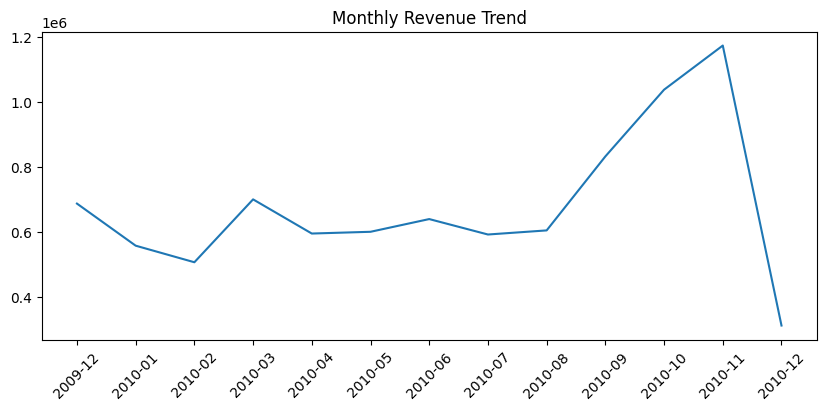

In [14]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,4))
plt.plot(monthly_revenue["Month"].astype(str), monthly_revenue["Revenue"])
plt.xticks(rotation=45)
plt.title("Monthly Revenue Trend")
plt.show()

## Top Product Revenue Analysis

This section analyzes product-level revenue contribution to identify the most important products driving overall sales.

We also evaluate revenue concentration using the Pareto principle (80/20 rule).

In [15]:
product_revenue = (
    df.groupby("Description")["Revenue"]
    .sum()
    .sort_values(ascending=False)
    .reset_index()
)

product_revenue.head(10)

,Description,Revenue
0,WHITE HANGING HEART T-LIGHT HOLDER,151624.31
1,REGENCY CAKESTAND 3 TIER,143893.35
2,Manual,98560.64
3,ASSORTED COLOUR BIRD ORNAMENT,70493.83
4,JUMBO BAG RED RETROSPOT,51759.30
5,POSTAGE,48741.08
6,ROTATING SILVER ANGELS T-LIGHT HLDR,40186.65
7,PAPER CHAIN KIT 50'S CHRISTMAS,36933.50
8,PARTY BUNTING,35035.90
9,EDWARDIAN PARASOL NATURAL,34044.75


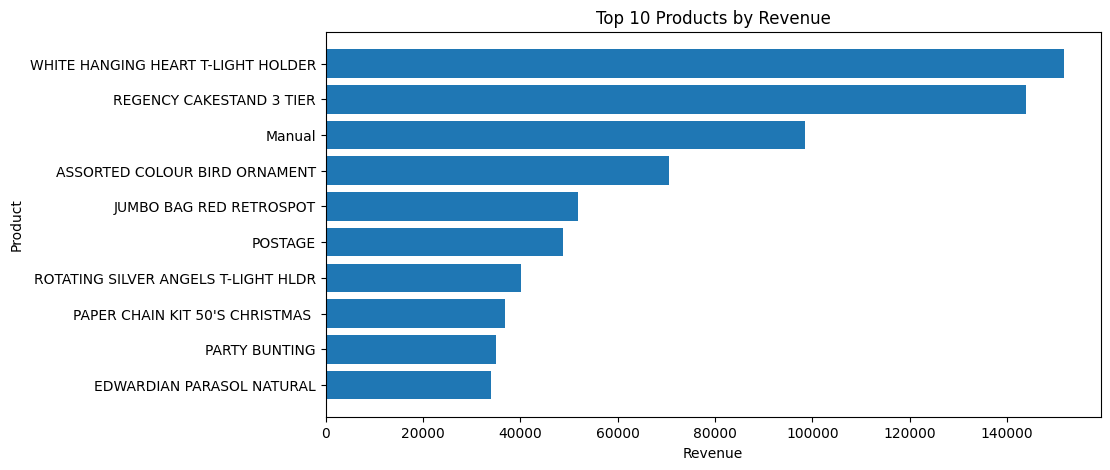

In [16]:
top_products = product_revenue.head(10)

import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))
plt.barh(top_products["Description"], top_products["Revenue"])
plt.gca().invert_yaxis()

plt.title("Top 10 Products by Revenue")
plt.xlabel("Revenue")
plt.ylabel("Product")

plt.show()

### Key Insight

A small number of products contribute a large share of total revenue.

This pattern suggests strong revenue concentration and follows the Pareto principle (80/20 rule), where a minority of SKUs drive the majority of sales.

In [17]:
product_revenue["RevenueShare"] = (
    product_revenue["Revenue"] / product_revenue["Revenue"].sum()
)

product_revenue["CumulativeShare"] = product_revenue["RevenueShare"].cumsum()

product_revenue.head()

,Description,Revenue,RevenueShare,CumulativeShare
0,WHITE HANGING HEART T-LIGHT HOLDER,151624.31,0.017168,0.017168
1,REGENCY CAKESTAND 3 TIER,143893.35,0.016292,0.033460
2,Manual,98560.64,0.011159,0.044619
3,ASSORTED COLOUR BIRD ORNAMENT,70493.83,0.007982,0.052601
4,JUMBO BAG RED RETROSPOT,51759.30,0.005860,0.058461


In [18]:
top_80 = product_revenue[product_revenue["CumulativeShare"] <= 0.8]

len(top_80)

992

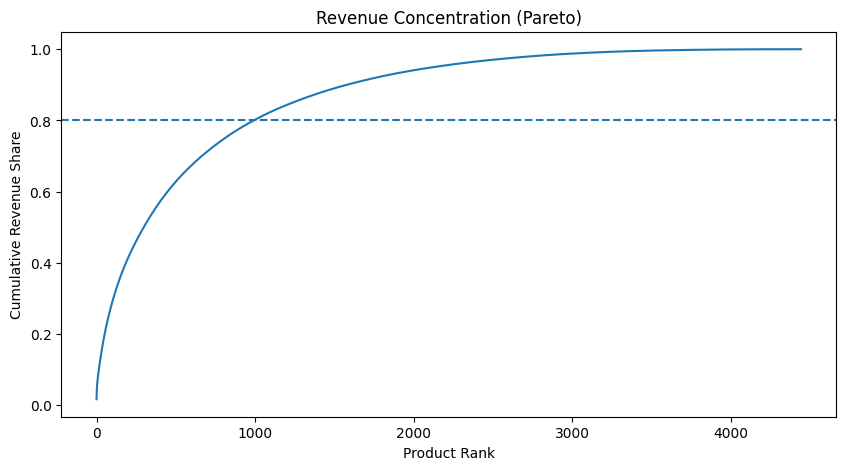

In [19]:
plt.figure(figsize=(10,5))

plt.plot(product_revenue["CumulativeShare"].values)

plt.axhline(0.8, linestyle="--")

plt.title("Revenue Concentration (Pareto)")
plt.xlabel("Product Rank")
plt.ylabel("Cumulative Revenue Share")

plt.show()

Revenue is highly concentrated across products.
Roughly 23% of products contribute around 80% of total revenue, indicating a strong Pareto distribution typical in retail datasets.